In [1]:
#%env JAX_PLATFORM=cpu
%env CUDA_VISIBLE_DEVICES=1
%env XLA_PYTHON_CLIENT_PREALLOCATE=false

import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

env: CUDA_VISIBLE_DEVICES=1
env: XLA_PYTHON_CLIENT_PREALLOCATE=false


In [2]:
from simulator import Simulator
from systems import ToyExample

system = ToyExample(x_dim=2, u_dim=2, y_dim=1, x_noise_std=0.01, y_noise_std=0.01)
y_ref = jnp.ones((100, system.y_dim))
u_ref = jnp.zeros((100, system.u_dim))
x_ref = jnp.zeros((100, system.x_dim))
sim = Simulator(system, mpc_horizon=10, Jy=10.0, Ju=0.01, Jx=0.0, Je=1.0, Q=0.01, R=0.01, key=jr.key(0))

In [3]:
def plot(sim, n=1, policy=False):
    for seed in range(n):
        res, rewards, _, _ = sim.rollout(y_ref, u_ref, x_ref, key=jr.key(seed), use_policy=policy)
        print(f"seed={seed},policy active={policy}, avg_reward={rewards.mean()}")
        plt.figure(figsize=(15, 10))
        for i in range(res.x.shape[-1]):
            plt.subplot(res.x.shape[-1], 3, 3*i + 1)
            mu, cov = res.est.mean[:, i], res.est.cov[:, i, i]
            plt.plot(mu, label=f"x{i}_est")
            plt.fill_between(range(len(mu)), mu - cov, mu + cov, alpha=0.5)
            plt.plot(res.x[:, i], label=f"x{i}")
            plt.plot(x_ref[:, i], ":k", label=f"x{i}_ref)")
            plt.legend()
            plt.grid()
        for i in range(res.u.shape[-1]):
            plt.subplot(res.u.shape[-1], 3, 3*i + 2)
            plt.plot(res.u[:, i], label=f"u{i}")
            plt.plot(res.a[:, i], label=f"a{i}")        
            plt.plot(u_ref[:, i], ":k", label=f"u{i}_ref)")
            plt.legend()
            plt.grid()
        for i in range(res.y.shape[-1]):
            plt.subplot(res.y.shape[-1], 3, 3*i + 3)
            plt.plot(res.y[:, i], label=f"y{i}")
            plt.plot(y_ref[:, i], ":k", label=f"y{i}_ref)")
            plt.legend()
            plt.grid()
        plt.show()       

seed=0,policy active=False, avg_reward=-1.9058884382247925


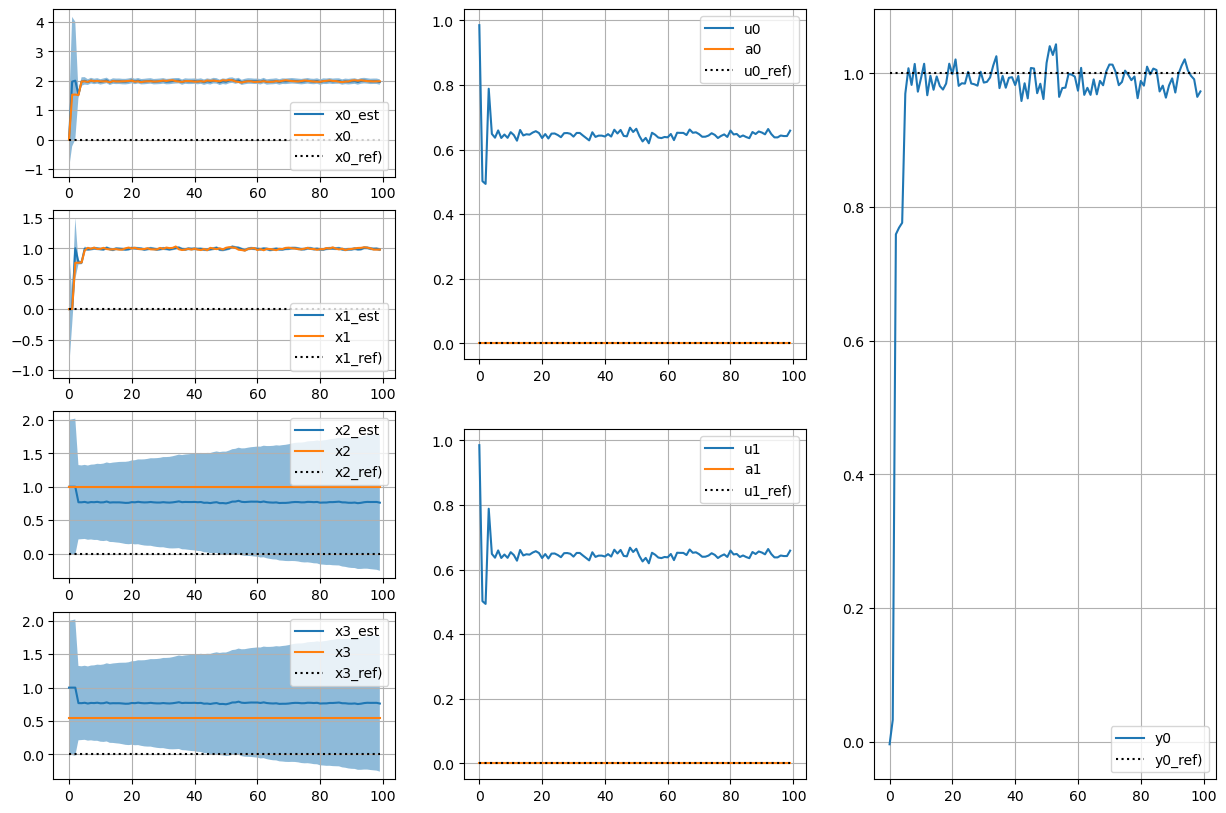

seed=0,policy active=True, avg_reward=-0.7595146894454956


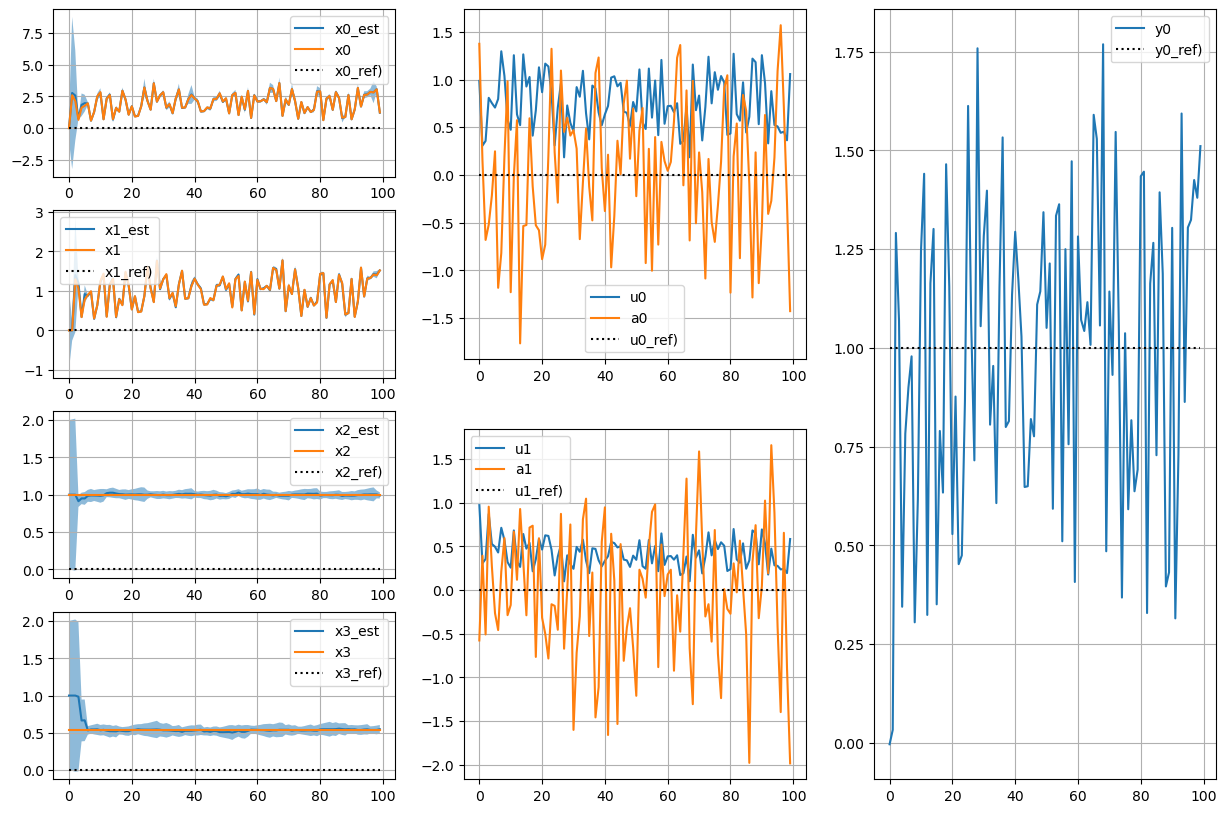

In [4]:
plot(sim, 1, policy=False)
plot(sim, 1, policy=True)

In [5]:
import optax
import equinox as eqx
from tqdm import tqdm

optimizer = optax.adam(1e-4)
opt_state = optimizer.init(eqx.filter(sim.policy, eqx.is_array))


@eqx.filter_jit
def step(sim, opt_state, *, key):
    keys = jr.split(key, 128)
    rollouts, rewards, V_est, A_est = jax.vmap(
        lambda k: sim.rollout(y_ref, u_ref, x_ref, key=k)
    )(keys)
    A_est = (A_est - A_est.mean()) / (A_est.std() + 1e-8)

    @eqx.filter_value_and_grad
    def loss_fn(policy):
        batch_loss = jax.vmap(jax.vmap(policy.loss))
        states = (rollouts.est, rollouts.ut)
        a, log_p = rollouts.a, rollouts.log_p
        return batch_loss(states, a, log_p, V_est, A_est).mean()

    policy = sim.policy
    for _ in range(10):
        loss, grads = loss_fn(policy)
        updates, opt_state = optimizer.update(
            grads, opt_state, eqx.filter(policy, eqx.is_array)
        )
        policy = eqx.apply_updates(policy, updates)

    sim = eqx.tree_at(lambda sim: sim.policy, sim, policy)
    return sim, opt_state, loss, rewards

def returns(rewards, gamma=1.0):
    step = lambda v, xi: (xi + gamma * v,) * 2
    scan = lambda xi: jax.lax.scan(step, 0.0, xi, reverse=True)[1]
    return jax.vmap(scan)(rewards).mean()

log_loss, log_rew = [], []
for key in (pbar := tqdm(jr.split(jr.key(0), 1000))):
    sim, opt_state, loss, rew = step(sim, opt_state, key=key)
    pbar.set_postfix(loss=loss.item(), rew=returns(rew).item())
    log_loss.append(loss.item())
    log_rew.append(returns(rew).item())
log_loss, log_rew = jnp.array(log_loss), jnp.array(log_rew)

100%|██████████| 1000/1000 [02:17<00:00,  7.26it/s, loss=0.0291, rew=-20.9]


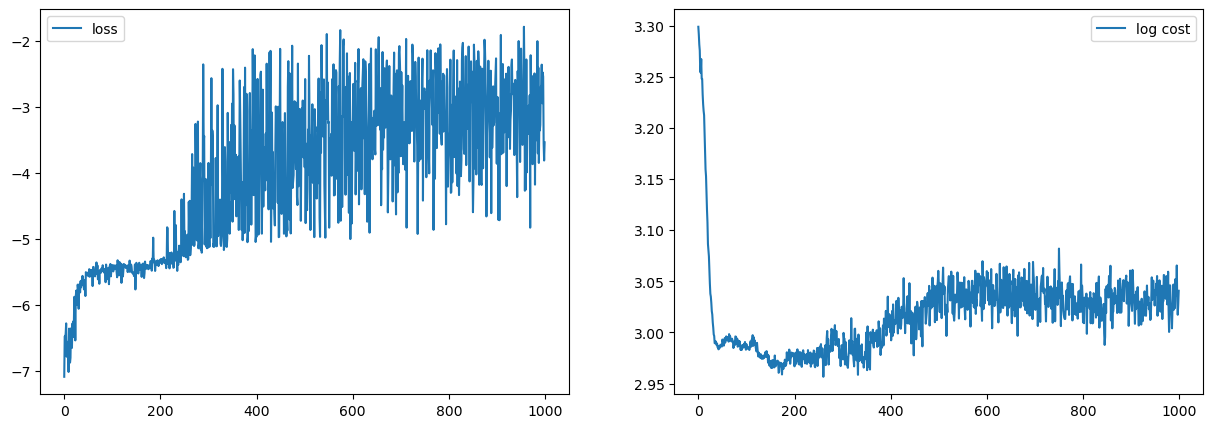

In [6]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(jnp.log(log_loss), label="loss")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(jnp.log(-log_rew), label="log cost")
plt.legend()

seed=0,policy active=True, avg_reward=-0.5699376463890076


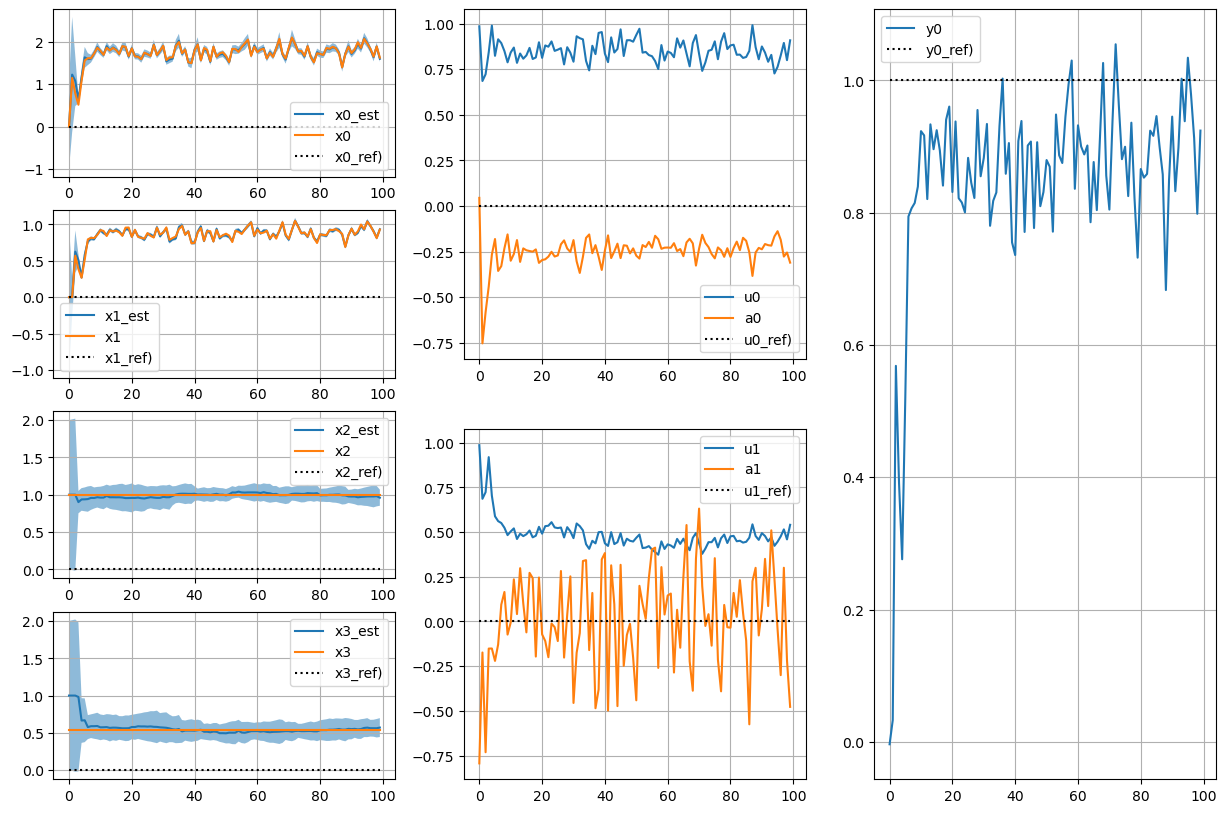

seed=1,policy active=True, avg_reward=-0.5313853621482849


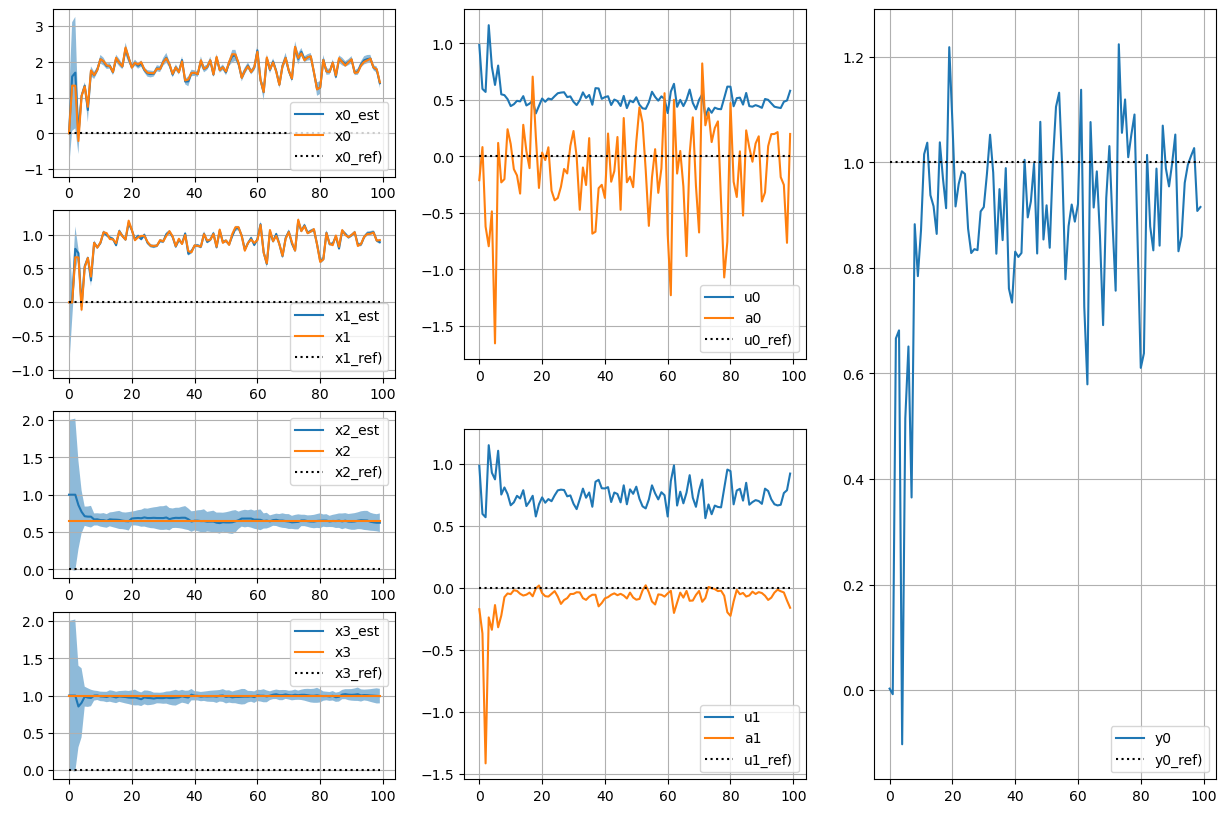

seed=2,policy active=True, avg_reward=-0.637748122215271


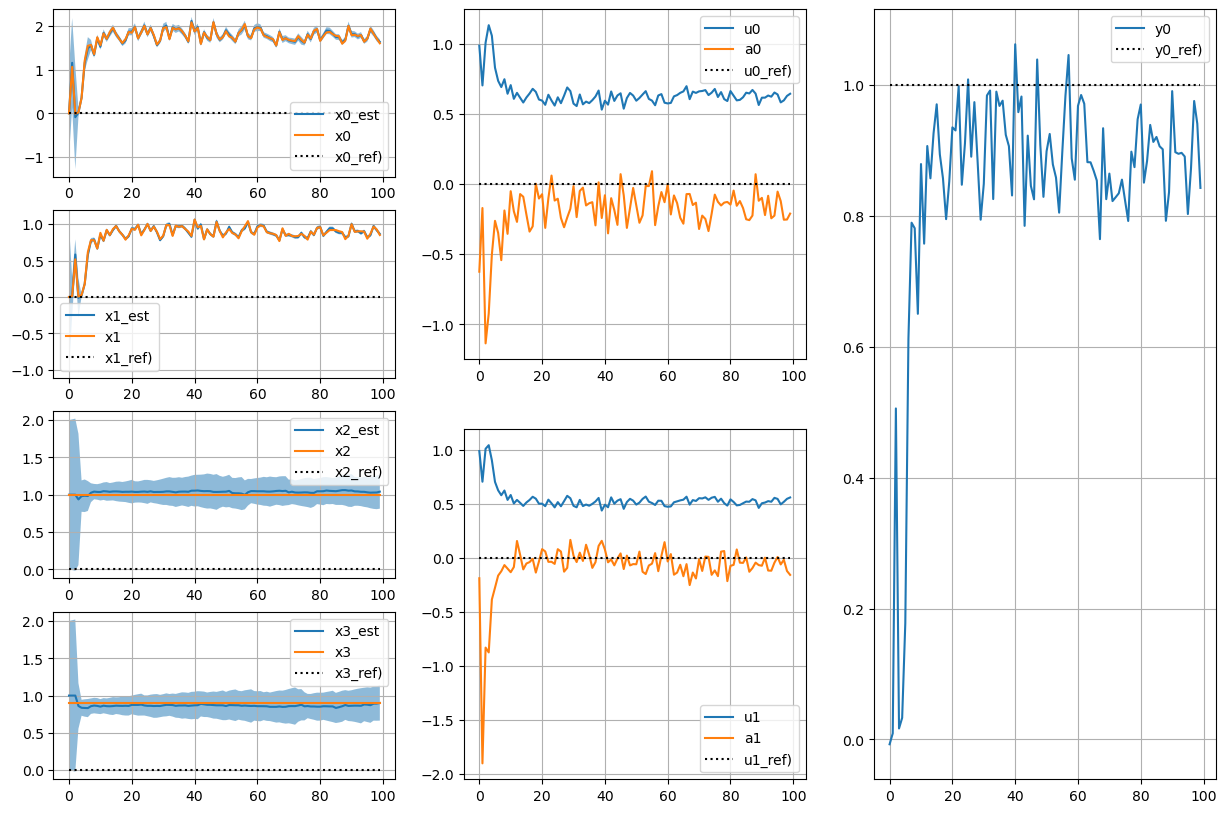

In [7]:
plot(sim, 3, policy=True)